In [1]:
"""
Implementação das rotinas clássicas de Hesthaven & Warburton
(Nodal Discontinuous Galerkin Methods, 2008) para o triângulo de referência:

  - Polinômios de Jacobi (JacobiP) e pontos de Gauss-Lobatto (JacobiGL)
  - Distribuição de nós "warp & blend" (Nodes2D)
  - Base modal ortonormal de Koornwinder/Dubiner no simplex 2D (Simplex2DP)
  - Matriz de Vandermonde 2D e base nodal (funções tipo Lagrange no triângulo)
"""

import numpy as np
from scipy.special import gamma


# ----------------------------------------------------------------------
# Polinômios de Jacobi 1D
# ----------------------------------------------------------------------
def JacobiP(x, alpha, beta, N):
    """Polinômio de Jacobi normalizado P_N^(alpha,beta) avaliado em x (array)."""
    x = np.asarray(x, dtype=float)
    PL = np.zeros((N + 1, x.size))

    gamma0 = (2 ** (alpha + beta + 1) / (alpha + beta + 1)
              * gamma(alpha + 1) * gamma(beta + 1) / gamma(alpha + beta + 1))
    PL[0] = 1.0 / np.sqrt(gamma0)
    if N == 0:
        return PL[0]

    gamma1 = (alpha + 1) * (beta + 1) / (alpha + beta + 3) * gamma0
    PL[1] = ((alpha + beta + 2) * x / 2 + (alpha - beta) / 2) / np.sqrt(gamma1)
    if N == 1:
        return PL[1]

    aold = 2 / (2 + alpha + beta) * np.sqrt((alpha + 1) * (beta + 1) / (alpha + beta + 3))
    for i in range(1, N):
        h1 = 2 * i + alpha + beta
        anew = (2 / (h1 + 2) * np.sqrt((i + 1) * (i + 1 + alpha + beta) * (i + 1 + alpha)
                                        * (i + 1 + beta) / (h1 + 1) / (h1 + 3)))
        bnew = -(alpha ** 2 - beta ** 2) / (h1 * (h1 + 2)) if h1 != 0 else 0.0
        PL[i + 1] = (1 / anew) * (-aold * PL[i - 1] + (x - bnew) * PL[i])
        aold = anew

    return PL[N]


def JacobiGQ(alpha, beta, N):
    """Pontos e pesos de quadratura de Gauss-Jacobi."""
    if N == 0:
        x = np.array([-(alpha - beta) / (alpha + beta + 2)])
        w = np.array([2.0])
        return x, w

    n = np.arange(0, N + 1)
    h1 = 2 * n + alpha + beta
    diag_main = -0.5 * (alpha ** 2 - beta ** 2) / (h1 + 2) / h1
    diag_main = np.where(h1 == 0, 0.0, diag_main)

    n_off = np.arange(1, N + 1)
    h1_off = h1[:N]
    diag_off = (2.0 / (h1_off + 2) *
                np.sqrt(n_off * (n_off + alpha + beta) * (n_off + alpha) * (n_off + beta)
                        / (h1_off + 1) / (h1_off + 3)))

    J = np.diag(diag_main) + np.diag(diag_off, 1)
    if alpha + beta < 10 * np.finfo(float).eps:
        J[0, 0] = 0.0
    J = J + J.T

    D, V = np.linalg.eigh(J)
    x = D
    w = (V[0, :] ** 2) * (2 ** (alpha + beta + 1) / (alpha + beta + 1)
                          * gamma(alpha + 1) * gamma(beta + 1) / gamma(alpha + beta + 1))
    return x, w


def JacobiGL(alpha, beta, N):
    """Pontos de Gauss-Lobatto-Jacobi (inclui -1 e 1)."""
    if N == 1:
        return np.array([-1.0, 1.0])
    xint, _ = JacobiGQ(alpha + 1, beta + 1, N - 2)
    return np.concatenate(([-1.0], xint, [1.0]))


def Vandermonde1D(N, r):
    V = np.zeros((len(r), N + 1))
    for j in range(N + 1):
        V[:, j] = JacobiP(r, 0, 0, j)
    return V


# ----------------------------------------------------------------------
# Warp & Blend (Warburton) para gerar nós no triângulo
# ----------------------------------------------------------------------
def Warpfactor(N, rout):
    LGLr = JacobiGL(0, 0, N)
    req = np.linspace(-1, 1, N + 1)
    Veq = Vandermonde1D(N, req)

    Nr = len(rout)
    Pmat = np.zeros((N + 1, Nr))
    for i in range(N + 1):
        Pmat[i, :] = JacobiP(rout, 0, 0, i)

    Lmat = np.linalg.solve(Veq.T, Pmat)
    warp = Lmat.T @ (LGLr - req)

    zerof = (np.abs(rout) < 1.0 - 1.0e-10).astype(float)
    sf = 1.0 - (zerof * rout) ** 2
    warp = warp / sf + warp * (zerof - 1.0)
    return warp


# alpha ótimo tabelado por Warburton para blending (N=1..15)
_ALPHA_OPT = [0.0000, 0.0000, 1.4152, 0.1001, 0.2751, 0.9800, 1.0999, 1.2832,
              1.3648, 1.4773, 1.4959, 1.5743, 1.5770, 1.6223, 1.6258]


def Nodes2D(N):
    """Nós warp&blend no triângulo equilátero (x, y)."""
    alpha = _ALPHA_OPT[N - 1] if 1 <= N <= 15 else 5.0 / 3.0

    Np = (N + 1) * (N + 2) // 2
    L1 = np.zeros(Np)
    L2 = np.zeros(Np)
    L3 = np.zeros(Np)
    sk = 0
    for n in range(1, N + 2):
        for m in range(1, N + 3 - n):
            L1[sk] = (n - 1) / N
            L3[sk] = (m - 1) / N
            L2[sk] = 1 - L1[sk] - L3[sk]
            sk += 1

    x = -L2 + L3
    y = (-L2 - L3 + 2 * L1) / np.sqrt(3)

    blend1 = 4 * L2 * L3
    blend2 = 4 * L1 * L3
    blend3 = 4 * L1 * L2

    warpf1 = Warpfactor(N, L3 - L2)
    warpf2 = Warpfactor(N, L1 - L3)
    warpf3 = Warpfactor(N, L2 - L1)

    warp1 = blend1 * warpf1 * (1 + (alpha * L1) ** 2)
    warp2 = blend2 * warpf2 * (1 + (alpha * L2) ** 2)
    warp3 = blend3 * warpf3 * (1 + (alpha * L3) ** 2)

    x = x + warp1 + np.cos(2 * np.pi / 3) * warp2 + np.cos(4 * np.pi / 3) * warp3
    y = y + 0 * warp1 + np.sin(2 * np.pi / 3) * warp2 + np.sin(4 * np.pi / 3) * warp3
    return x, y


def xytors(x, y):
    """Converte coordenadas do triângulo equilátero (x,y) para o
    triângulo de referência (r,s) com vértices (-1,-1),(1,-1),(-1,1)."""
    L1 = (np.sqrt(3) * y + 1) / 3
    L2 = (-3 * x - np.sqrt(3) * y + 2) / 6
    L3 = (3 * x - np.sqrt(3) * y + 2) / 6
    r = -L2 + L3 - L1
    s = -L2 - L3 + L1
    return r, s


def rstoab(r, s):
    """Coordenadas colapsadas (a,b) usadas na base de Koornwinder/Dubiner."""
    a = np.where(s != 1, 2 * (1 + r) / (1 - s + 1e-300) - 1, -1.0)
    b = s
    return a, b


# ----------------------------------------------------------------------
# Base modal (Koornwinder/Dubiner) e Vandermonde 2D
# ----------------------------------------------------------------------
def Simplex2DP(a, b, i, j):
    h1 = JacobiP(a, 0, 0, i)
    h2 = JacobiP(b, 2 * i + 1, 0, j)
    return np.sqrt(2.0) * h1 * h2 * (1 - b) ** i


def modes_ij(N):
    """Lista ordenada [(i,j), ...] dos pares que indexam os Np modos, i+j<=N."""
    return [(i, j) for i in range(N + 1) for j in range(N - i + 1)]


def Vandermonde2D(N, r, s):
    a, b = rstoab(r, s)
    Np = (N + 1) * (N + 2) // 2
    V = np.zeros((len(r), Np))
    for k, (i, j) in enumerate(modes_ij(N)):
        V[:, k] = Simplex2DP(a, b, i, j)
    return V


def warp_and_blend_nodes(N):
    """Retorna os nós (r,s) no triângulo de referência (-1,-1),(1,-1),(-1,1)."""
    x, y = Nodes2D(N)
    r, s = xytors(x, y)
    return r, s


Figuras salvas: nodes.png, modal_basis_contour.png, nodal_basis_contour.png, modal_basis_surface.png, nodal_basis_surface.png


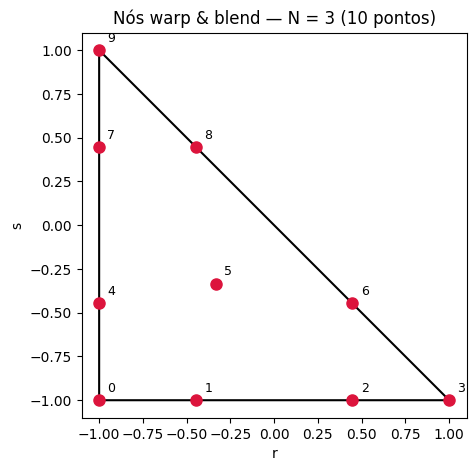

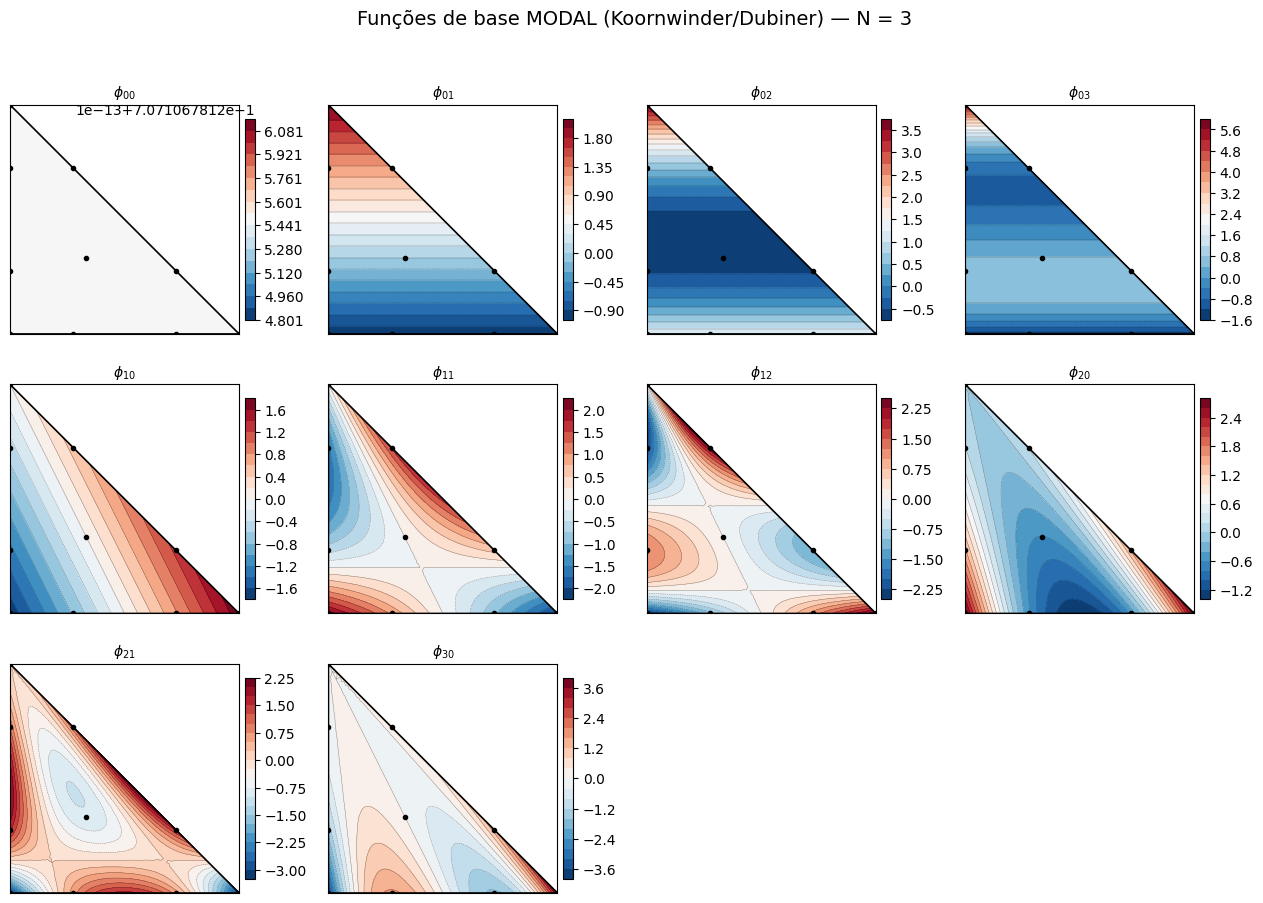

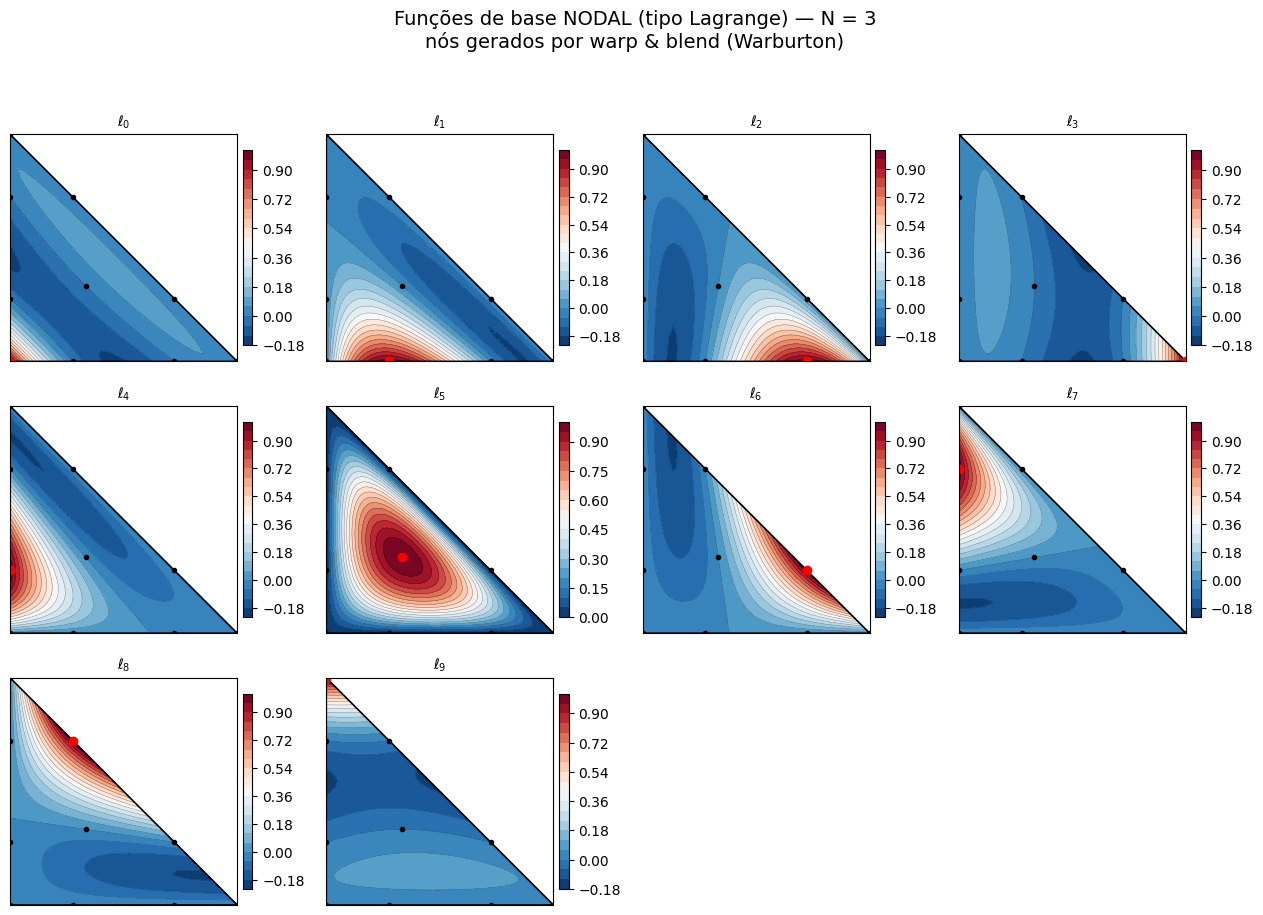

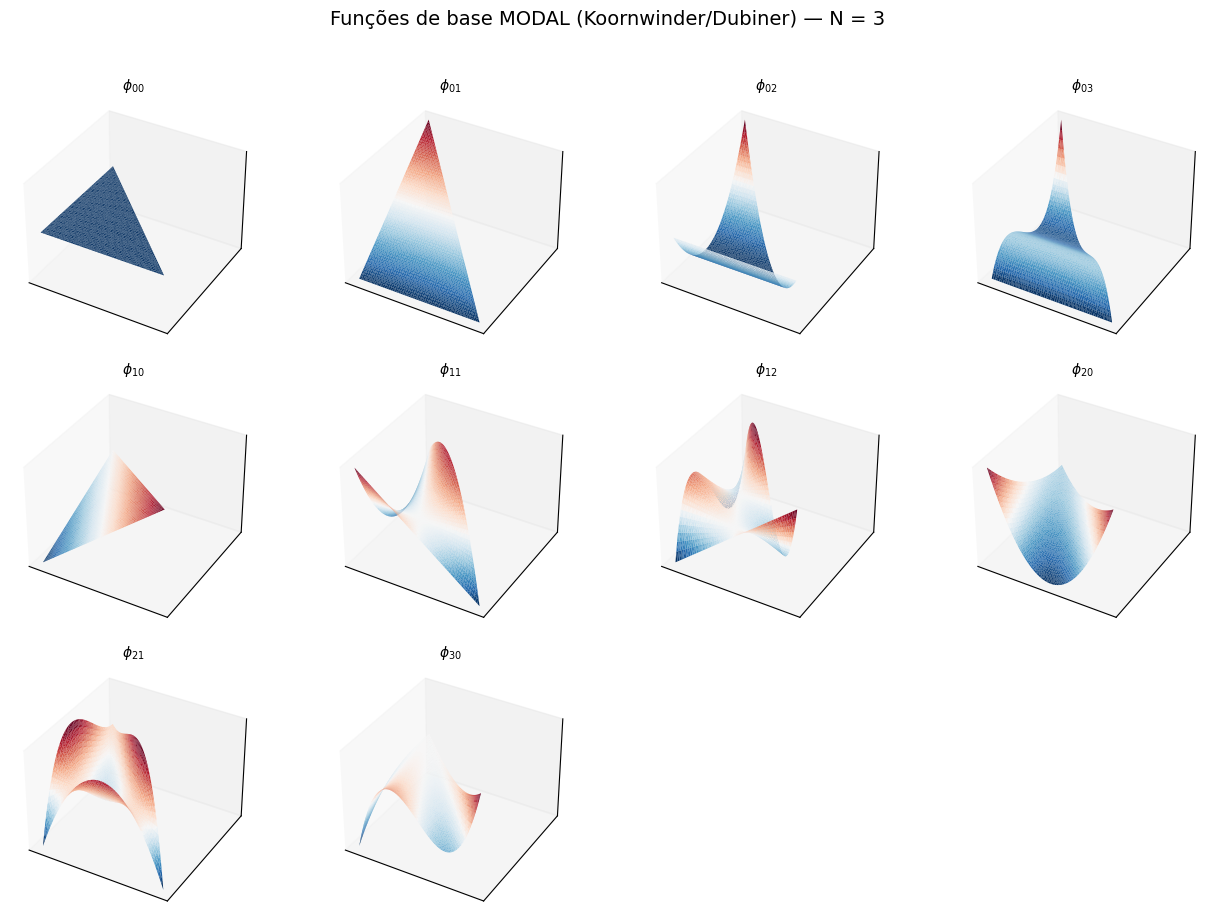

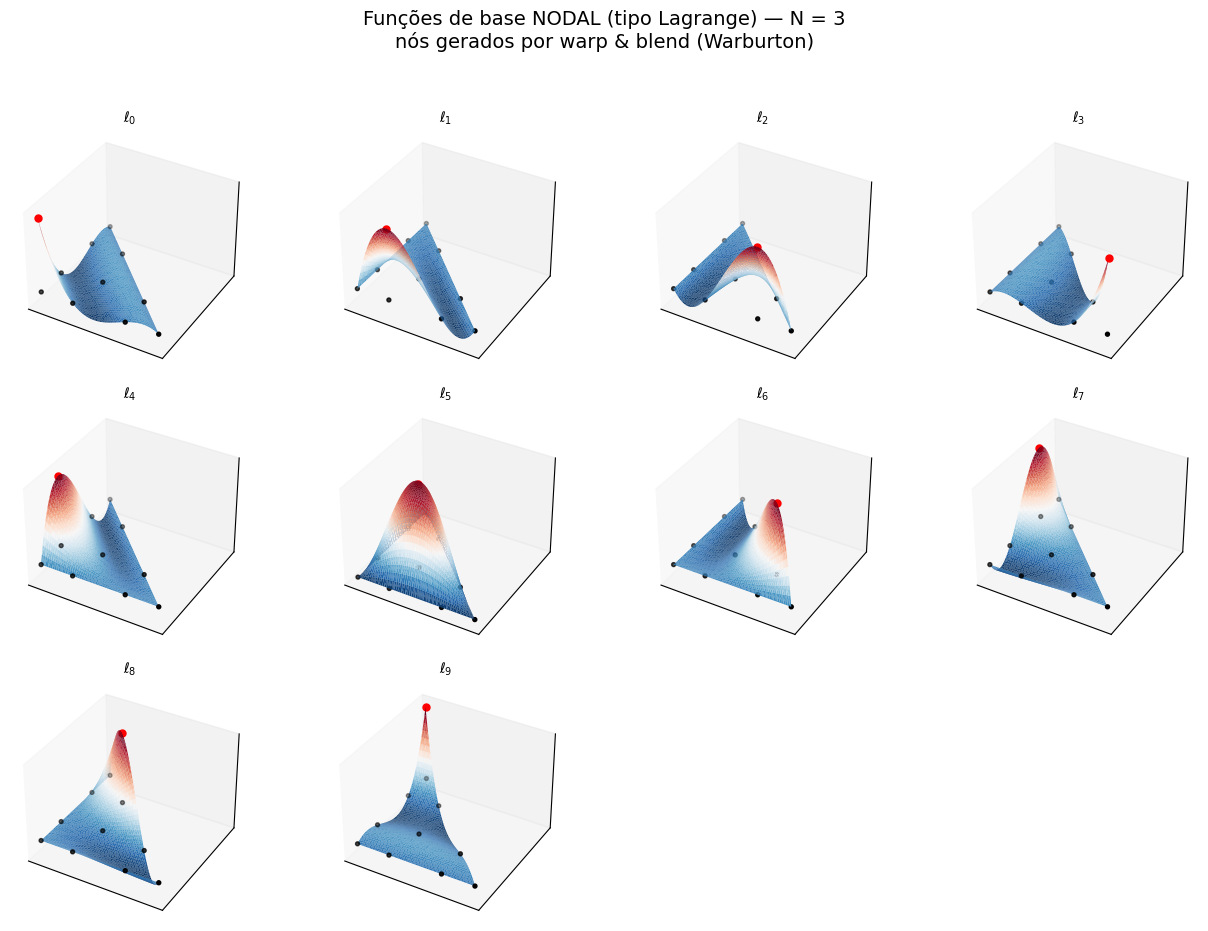

In [2]:
"""
Plota as funções de base MODAL (Koornwinder/Dubiner) e NODAL (tipo Lagrange)
no triângulo de referência, com os nós gerados pelo método warp&blend
(Warburton) usado no DGTD, para uma ordem N escolhida.

Uso:
    from plot_basis import plot_modal_and_nodal_basis
    plot_modal_and_nodal_basis(N=3)
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necessário p/ 3D)


def _reference_triangle_mesh(n_per_side=40):
    """Malha fina (Delaunay) cobrindo o triângulo de referência
    com vértices (-1,-1), (1,-1), (-1,1)."""
    pts_r, pts_s = [], []
    for i in range(n_per_side + 1):
        for j in range(n_per_side + 1 - i):
            r = -1 + 2 * i / n_per_side
            s = -1 + 2 * j / n_per_side
            pts_r.append(r)
            pts_s.append(s)
    r = np.array(pts_r)
    s = np.array(pts_s)
    tri = Triangulation(r, s)
    return r, s, tri


def plot_modal_and_nodal_basis(N=3, n_per_side=60, cmap="RdBu_r", style="contour",
                                n_levels=20):
    """
    Gera duas figuras (matplotlib) com as Np = (N+1)(N+2)/2 funções
    de base modal e nodal do triângulo de referência, usando os nós
    warp&blend de ordem N.

    Parameters
    ----------
    N : int
        Ordem polinomial (grau máximo). Para N=3, Np = 10.
    n_per_side : int
        Resolução da malha fina usada para desenhar as funções.
    cmap : str
        Colormap usado.
    style : {"contour", "surface"}
        "contour" -> gráfico de contorno preenchido 2D (tricontourf).
        "surface" -> superfície 3D (plot_trisurf).
    n_levels : int
        Número de níveis de cor no gráfico de contorno.

    Returns
    -------
    (fig_modal, fig_nodal) : tupla de figuras matplotlib
    """
    Np = (N + 1) * (N + 2) // 2

    # 1) nós warp & blend no triângulo de referência
    rn, sn = warp_and_blend_nodes(N)

    # 2) matriz de Vandermonde nos nós -> define a base nodal
    V = Vandermonde2D(N, rn, sn)
    Vinv = np.linalg.inv(V)

    # 3) malha fina para desenhar as funções
    r_fine, s_fine, tri = _reference_triangle_mesh(n_per_side)
    V_fine = Vandermonde2D(N, r_fine, s_fine)      # phi_k(r,s) na malha fina
    L_fine = V_fine @ Vinv                          # l_m(r,s) = funções nodais

    ij_list = modes_ij(N)

    ncols = int(np.ceil(np.sqrt(Np)))
    nrows = int(np.ceil(Np / ncols))

    triangle_r = [-1, 1, -1, -1]
    triangle_s = [-1, -1, 1, -1]

    use_3d = (style == "surface")
    subplot_kw = {"projection": "3d"} if use_3d else {}

    # ---------- Figura 1: funções MODAIS ----------
    fig_modal = plt.figure(figsize=(3.2 * ncols, 3.0 * nrows))
    fig_modal.suptitle(f"Funções de base MODAL (Koornwinder/Dubiner) — N = {N}",
                        fontsize=14, y=1.02)
    for k in range(Np):
        ax = fig_modal.add_subplot(nrows, ncols, k + 1, **subplot_kw)
        phi_k = V_fine[:, k]
        i, j = ij_list[k]
        if use_3d:
            ax.plot_trisurf(tri.x, tri.y, phi_k, triangles=tri.triangles,
                             cmap=cmap, linewidth=0, antialiased=True)
            ax.set_zticks([])
            ax.view_init(elev=35, azim=-60)
        else:
            cs = ax.tricontourf(tri, phi_k, levels=n_levels, cmap=cmap)
            ax.tricontour(tri, phi_k, levels=n_levels, colors="k",
                           linewidths=0.3, alpha=0.5)
            ax.plot(triangle_r, triangle_s, "k-", lw=1.2)
            ax.plot(rn, sn, "o", color="k", ms=3)
            ax.set_aspect("equal")
            fig_modal.colorbar(cs, ax=ax, shrink=0.75, pad=0.02)
        ax.set_title(f"$\\phi_{{{i}{j}}}$", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig_modal.tight_layout()

    # ---------- Figura 2: funções NODAIS ----------
    fig_nodal = plt.figure(figsize=(3.2 * ncols, 3.0 * nrows))
    fig_nodal.suptitle(f"Funções de base NODAL (tipo Lagrange) — N = {N}\n"
                        "nós gerados por warp & blend (Warburton)",
                        fontsize=14, y=1.03)
    for m in range(Np):
        ax = fig_nodal.add_subplot(nrows, ncols, m + 1, **subplot_kw)
        l_m = L_fine[:, m]
        if use_3d:
            ax.plot_trisurf(tri.x, tri.y, l_m, triangles=tri.triangles,
                             cmap=cmap, linewidth=0, antialiased=True)
            # marca todos os nós no plano z=0 e destaca o nó "dono" da função
            ax.scatter(rn, sn, np.zeros_like(rn), color="k", s=8)
            ax.scatter([rn[m]], [sn[m]], [1.0], color="red", s=25)
            ax.set_zticks([])
            ax.view_init(elev=35, azim=-60)
        else:
            cs = ax.tricontourf(tri, l_m, levels=n_levels, cmap=cmap)
            ax.tricontour(tri, l_m, levels=n_levels, colors="k",
                           linewidths=0.3, alpha=0.5)
            ax.plot(triangle_r, triangle_s, "k-", lw=1.2)
            ax.plot(rn, sn, "o", color="k", ms=3)
            ax.plot([rn[m]], [sn[m]], "o", color="red", ms=6)
            ax.set_aspect("equal")
            fig_nodal.colorbar(cs, ax=ax, shrink=0.75, pad=0.02)
        ax.set_title(f"$\\ell_{{{m}}}$", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig_nodal.tight_layout()

    return fig_modal, fig_nodal


def plot_node_distribution(N=3, ax=None):
    """Plota apenas a distribuição de nós warp&blend no triângulo de referência."""
    rn, sn = warp_and_blend_nodes(N)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure
    triangle_r = [-1, 1, -1, -1]
    triangle_s = [-1, -1, 1, -1]
    ax.plot(triangle_r, triangle_s, "k-", lw=1.5)
    ax.plot(rn, sn, "o", color="crimson", ms=8)
    for k, (x, y) in enumerate(zip(rn, sn)):
        ax.annotate(str(k), (x, y), textcoords="offset points",
                    xytext=(6, 6), fontsize=9)
    ax.set_aspect("equal")
    ax.set_title(f"Nós warp & blend — N = {N} ({len(rn)} pontos)")
    ax.set_xlabel("r"); ax.set_ylabel("s")
    return fig


if __name__ == "__main__":
    N = 3
    fig0 = plot_node_distribution(N)
    fig0.savefig("nodes.png", dpi=130, bbox_inches="tight")

    # gráficos de contorno 2D (padrão)
    fig_modal, fig_nodal = plot_modal_and_nodal_basis(N, style="contour")
    fig_modal.savefig("modal_basis_contour.png", dpi=130, bbox_inches="tight")
    fig_nodal.savefig("nodal_basis_contour.png", dpi=130, bbox_inches="tight")

    # opcional: também gera a versão em superfície 3D
    fig_modal_3d, fig_nodal_3d = plot_modal_and_nodal_basis(N, style="surface")
    fig_modal_3d.savefig("modal_basis_surface.png", dpi=130, bbox_inches="tight")
    fig_nodal_3d.savefig("nodal_basis_surface.png", dpi=130, bbox_inches="tight")

    print("Figuras salvas: nodes.png, modal_basis_contour.png, "
          "nodal_basis_contour.png, modal_basis_surface.png, nodal_basis_surface.png")
